In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
import os

if not os.path.exists('pictures'):
    os.mkdir('pictures')

# 6

### 6.1

Собрали схему из пункта с этими параметрами

In [30]:
R_1 = np.float64('5.492e3')  # Ом
R_2 = np.float64('0.986e3')  # Ом
R_3 = np.float64('18.09e3')  # Ом
R_4 = np.float64('17.973e3') # Ом
R_5 = np.float64('0.9825e3') # Ом

R = np.float64('294.7')      # Ом

C_1 = np.float64('68e-12')   # Ф
C_2 = np.float64('20e-12')   # Ф
C_3 = np.float64('561e-12')  # Ф
C_4 = np.float64('3.32e-9')  # Ф
C_5 = np.float64('6.05e-6')  # Ф

L = np.float64('47e-6')      # мкГн

In [31]:
U_P2 = np.float64('-10') # В

Включим и замеряем выходы транзисторов

In [32]:
data_6_1_1 = {
    "VT1": {
        "U_K": 9.9941, # В
        "U_E": -0.6014, # В
        "U_B": -0.002, # В
    },
    "VT2": {
        "U_K": 9.9941, # В
        "U_E": -0.599, # В
        "U_B": -0.0005, # В
    }
}

In [33]:
I_E1 = (data_6_1_1["VT1"]["U_E"] - U_P2) / R_3
print(f"I_E1 = {(I_E1*1e3):.3f} мА")

I_E2 = (data_6_1_1["VT2"]["U_E"] - U_P2) / R_4
print(f"I_E2 = {(I_E2*1e3):.3f} мА")

I_E1 = 0.520 мА
I_E2 = 0.523 мА


In [34]:
# Постоянная
U_T = np.float64('25e-3') # В

In [35]:
I_C = 0.5 * (I_E1 + I_E2)
print(f"I_C = {(I_C*1e3):.3f} мА")

I_C = 0.521 мА


In [36]:
S = I_C / U_T
print(f"S = {S:.3f} ОМ^{-1}")

S = 0.021 ОМ^-1


In [37]:
f_r = np.float64('1.01') # МГц

In [38]:
data_6_1_3 = pd.read_csv("data_6_1_3.csv")
data_6_1_3.head()

,U_in,U_out
0,10,80
1,20,160
2,30,239
3,40,319
4,50,410


In [39]:
data_6_1_3["K"] = data_6_1_3["U_out"] / data_6_1_3["U_in"]

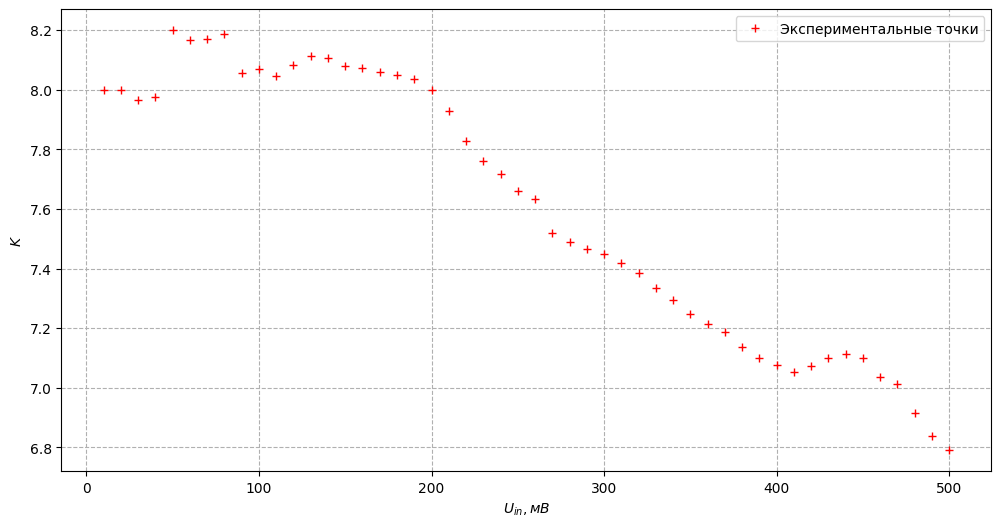

In [40]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle="--")

plt.errorbar(x=data_6_1_3["U_in"], y=data_6_1_3["K"], fmt="+r", label="Экспериментальные точки")

plt.xlabel(r"$U_{in}, мВ$")
plt.ylabel(r"$K$")

plt.legend()
plt.savefig("pictures/6_1_3_graph.pdf")
plt.show()

Замкнем $R = 0$ и повторим измерения

In [41]:
data_6_1_4 = pd.read_csv("data_6_1_4.csv")
data_6_1_4.head()

,U_in,U_out
0,500,6738
1,430,6738
2,350,6574
3,270,6265
4,200,5750


In [42]:
data_6_1_4["K"] = data_6_1_4["U_out"] / data_6_1_4["U_in"]

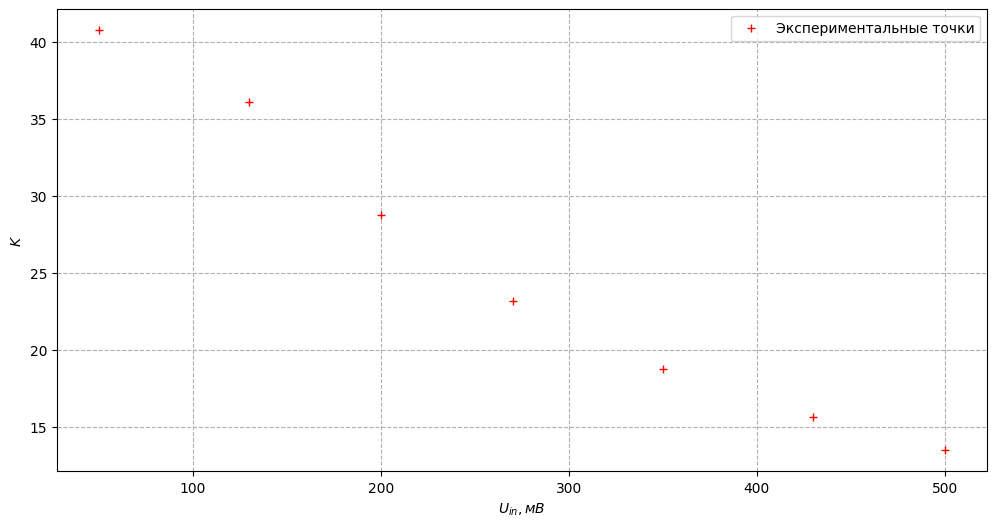

In [43]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle="--")

plt.errorbar(x=data_6_1_4["U_in"], y=data_6_1_4["K"], fmt="+r", label="Экспериментальные точки")

plt.xlabel(r"$U_{in}, мВ$")
plt.ylabel(r"$K$")

plt.legend()
plt.savefig("pictures/6_1_4_graph.pdf")
plt.show()

Выставим $U_{in} = 250~\text{мВ}$, так попадаем в линейный участок

In [44]:
data_6_1_5 = pd.read_csv("data_6_1_5.csv")
data_6_1_5.head()

,U_out,f
0,3600,1.02
1,3985,1.01
2,3579,1.00
3,2840,0.99
4,2220,0.98


In [45]:
data_6_1_5["K"] = data_6_1_5["U_out"] / 250

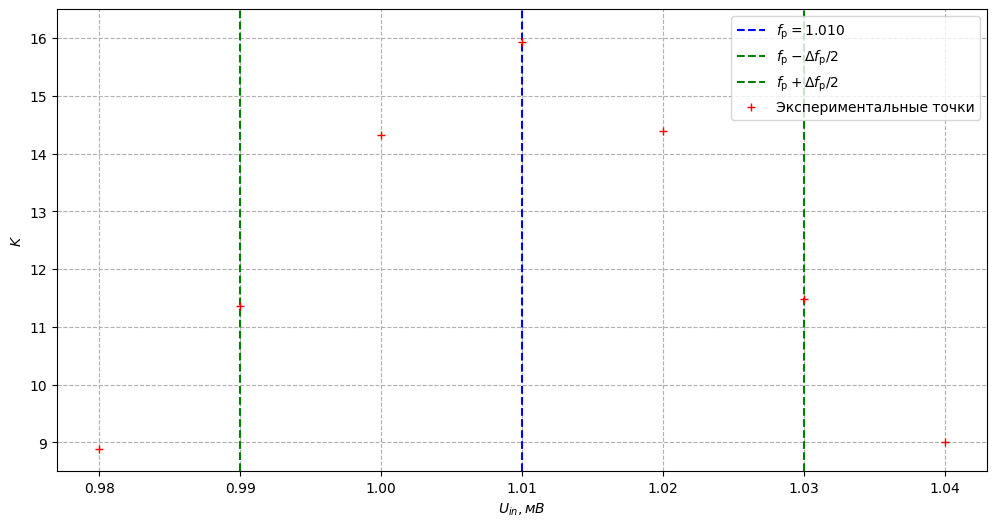

In [50]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle="--")

plt.errorbar(x=data_6_1_5["f"], y=data_6_1_5["K"], fmt="+r", label="Экспериментальные точки")

plt.vlines(x=f_r, ymin=8.5, ymax=16.5, linestyles="--", colors="blue", label=rf"$f_\text{{р}} = {f_r:.3f}$")

plt.vlines(x=f_r - 0.02, ymin=8.5, ymax=16.5, linestyles="--", colors="green", label=r"$f_\text{р} - \Delta f_\text{р} / 2$")
plt.vlines(x=f_r + 0.02, ymin=8.5, ymax=16.5, linestyles="--", colors="green", label=r"$f_\text{р} + \Delta f_\text{р} / 2$")
plt.ylim(8.5, 16.5)

plt.xlabel(r"$U_{in}, мВ$")
plt.ylabel(r"$K$")

plt.legend()
plt.savefig("pictures/6_1_5_graph.pdf")
plt.show()

### 6.2